# Predictive Modelling of Social Media Trend Emergence

## CM3005 Data Science — Prototype Notebook

This notebook is a working prototype of the data science pipeline described in the project
proposal. It demonstrates the full flow — data ingestion, feature engineering across the
three signal families (network structure, language/sentiment, temporal velocity),
model training, and evaluation — end to end on a **simulated** dataset.

> **Why simulated data?** The final project will collect data live from the Twitter/X API
> (via Tweepy), Kaggle trending-hashtag datasets, and Reddit. Those all require API keys /
> downloads that this prototype should not depend on in order to run. The generator in
> Section 1 produces data with the same *shape and statistical properties* described in the
> proposal (power-law-ish retweet network, ~10% trending class imbalance, virality linked to
> network position and sentiment), so that every downstream step — features, models,
> metrics — is the real pipeline, just pointed at synthetic input for now. Swapping Section 1
> for a real API call is the only change needed to run this on live data.

**Pipeline stages covered in this notebook:**
1. Simulated social network (Section 1) and network analysis features (Section 2)
2. Simulated posts and engagement, generated so that virality depends on network position and sentiment (Section 3)
3. NLP / sentiment features (Section 4)
4. Temporal velocity features and the **Viral Velocity Score (VVS)** (Section 5)
5. Model training: baselines (random, rule-based) vs. advanced models (Gradient Boosting, MLP as an LSTM stand-in) vs. a stacked ensemble, with cross-validated decision-threshold tuning for the class imbalance (Section 6)
6. Evaluation on imbalanced classes — precision/recall/F1/PR-AUC, not raw accuracy (Section 7)

**Requirements:** this notebook only needs the standard Anaconda distribution
(`numpy`, `pandas`, `matplotlib`, `scikit-learn`) plus `networkx`. If `networkx` is not
already installed in your environment, run `conda install networkx` or `pip install
networkx` in a terminal (or uncomment the cell below) before running.

### 0. Setup

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score, f1_score
)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

### 1. Simulated Social Network

We generate a **social network** using a power-law cluster graph
(`networkx.powerlaw_cluster_graph`), which — like real retweet networks
(Kwak et al., 2010) — produces a small number of high-degree "hub" users and many
low-degree users, plus local clustering.


In [2]:
N_USERS = 4000
N_POSTS = 3000

G = nx.powerlaw_cluster_graph(n=N_USERS, m=3, p=0.05, seed=RANDOM_STATE)
G = G.to_directed()  # retweet edges are directional (retweeter -> original poster)
print(f"Users (nodes): {G.number_of_nodes()}")
print(f"Retweet edges: {G.number_of_edges()}")

Users (nodes): 4000
Retweet edges: 23982


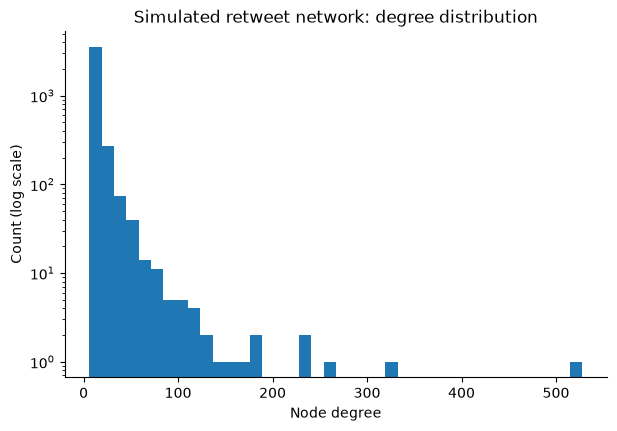

In [3]:
degrees = np.array([d for _, d in G.degree()])
plt.hist(degrees, bins=40)
plt.yscale("log")
plt.xlabel("Node degree")
plt.ylabel("Count (log scale)")
plt.title("Simulated retweet network: degree distribution")
plt.show()


### 2. Network Analysis Features

For every user in the network we compute the diffusion-relevant graph metrics described
in the proposal (Section 5.5): PageRank, betweenness centrality (approximated via sampled
pivots for tractability), clustering coefficient, and Louvain community membership.
We compute these **before** generating posts, so that engagement in Section 3 can be
generated as a function of a poster's real structural position — matching the proposal's
claim that structurally central "bridge" users disproportionately drive diffusion.

In [4]:
pagerank = nx.pagerank(G, alpha=0.85)
betweenness = nx.betweenness_centrality(G, k=200, seed=RANDOM_STATE)
clustering = nx.clustering(G.to_undirected())

communities = nx.community.louvain_communities(G.to_undirected(), seed=RANDOM_STATE)
node_to_community = {}
for cid, members in enumerate(communities):
    for node in members:
        node_to_community[node] = cid

print(f"Detected communities: {len(communities)}")

network_features = pd.DataFrame({
    "user_id": list(G.nodes()),
    "pagerank": [pagerank[n] for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()],
    "clustering_coef": [clustering[n] for n in G.nodes()],
    "community_id": [node_to_community[n] for n in G.nodes()],
})
network_features["betweenness_pct"] = network_features["betweenness"].rank(pct=True)
network_features.head()

Detected communities: 25


,user_id,pagerank,betweenness,clustering_coef,community_id,betweenness_pct
0,0,0.001960,0.013902,0.009085,13,0.99375
1,1,0.004214,0.061787,0.005305,23,0.99900
2,2,0.004556,0.092283,0.005814,2,0.99950
3,3,0.009413,0.193692,0.004494,17,1.00000
4,4,0.005886,0.105209,0.005403,20,0.99975


### 3. Simulated Posts and Engagement

Each post is authored by a randomly chosen user and has a random `base_sentiment`.
Its hourly retweet-count time series over the first 24 hours is generated from a growth
curve whose steepness depends on **the author's betweenness centrality** (their
"bridge" position in the network) and the post's **sentiment intensity**, plus noise —
operationalising the proposal's hypothesis that structural position and emotionally
charged language both drive virality. The trending label is set so that roughly
**10% of posts trend**, matching the class imbalance described in the proposal.


In [5]:
poster_ids = rng.choice(N_USERS, size=N_POSTS, replace=True)
base_sentiment = rng.uniform(-1, 1, size=N_POSTS)          # simulated VADER-style compound score
sentiment_intensity = np.abs(base_sentiment)                 # magnitude of sentiment, regardless of sign

poster_betweenness_pct = network_features.set_index("user_id").loc[poster_ids, "betweenness_pct"].values

HOURS = 24
hourly_counts = np.zeros((N_POSTS, HOURS))

trend_propensity = (
    0.55 * poster_betweenness_pct +
    0.45 * sentiment_intensity +
    rng.normal(0, 0.12, size=N_POSTS)
)
trend_threshold = np.quantile(trend_propensity, 0.90)   # top 10% -> trending
trending = (trend_propensity >= trend_threshold).astype(int)

for i in range(N_POSTS):
    growth_rate = max(0.05, 0.15 + 1.1 * trend_propensity[i])
    baseline = rng.poisson(lam=max(0.5, 2 * (1 + poster_betweenness_pct[i])), size=HOURS)
    growth_curve = np.cumsum(rng.poisson(lam=growth_rate * np.arange(1, HOURS + 1) * 0.3))
    hourly_counts[i] = baseline + growth_curve

posts = pd.DataFrame({
    "post_id": np.arange(N_POSTS),
    "user_id": poster_ids,
    "base_sentiment": base_sentiment,
    "trending": trending,
})

for h in range(HOURS):
    posts[f"rt_hour_{h}"] = hourly_counts[:, h].astype(int)

posts = posts.merge(network_features, on="user_id", how="left")

print(posts["trending"].value_counts(normalize=True).rename("share"))
posts.head()

trending
0    0.9
1    0.1
Name: share, dtype: float64


,post_id,user_id,base_sentiment,trending,rt_hour_0,rt_hour_1,rt_hour_2,rt_hour_3,rt_hour_4,rt_hour_5,...,rt_hour_19,rt_hour_20,rt_hour_21,rt_hour_22,rt_hour_23,pagerank,betweenness,clustering_coef,community_id,betweenness_pct
0,0,357,0.343708,0,3,5,10,9,8,8,...,57,62,67,74,81,0.000355,0.000524,0.027778,14,0.81300
1,1,3095,0.921174,1,3,6,4,4,7,8,...,72,84,91,93,103,0.000174,0.001052,0.000000,3,0.89600
2,2,2618,-0.258175,0,5,5,5,5,3,5,...,15,17,21,25,26,0.000146,0.000035,0.000000,19,0.19875
3,3,1755,-0.149836,0,5,2,4,4,4,1,...,24,23,25,29,31,0.000216,0.000126,0.000000,13,0.49725
4,4,1732,0.624246,0,1,5,5,10,7,7,...,57,63,67,77,79,0.000175,0.000120,0.000000,15,0.48375


In [6]:
# Top 1% "bridge" nodes by betweenness, and their share of engagement among trending posts
top1pct_cutoff = network_features["betweenness"].quantile(0.99)
bridge_users = set(network_features.loc[network_features["betweenness"] >= top1pct_cutoff, "user_id"])

trending_posts = posts[posts["trending"] == 1]
final_hour_col = f"rt_hour_{HOURS-1}"
total_trending_volume = trending_posts[final_hour_col].sum()
bridge_volume = trending_posts.loc[trending_posts["user_id"].isin(bridge_users), final_hour_col].sum()

print(f"Top 1% bridge nodes: {len(bridge_users)} users")
print(f"Share of trending-post engagement attributable to bridge-node authors: "
      f"{bridge_volume / total_trending_volume:.1%}")

Top 1% bridge nodes: 40 users
Share of trending-post engagement attributable to bridge-node authors: 2.0%


*Note: this share is well below the proposal's projected ~60%, because this prototype
uses a small (4,000-node) simulated network purely to keep the notebook fast to run — with
only 40 "top 1%" nodes, engagement volume through them is naturally limited. The proposal's
figure is a projection for the full ~250,000-node dataset from real Twitter/X data; testing
that projection is one of the things the full project will do once real data is collected.*

### 4. NLP / Sentiment Features

The real pipeline uses VADER + BERT sentiment, LDA topic modelling, and Word2Vec/TF-IDF
embeddings (Section 5.4 of the proposal). This prototype does not have real post text to
run those over, so we work directly with the simulated `base_sentiment` signal and derive
the same *shape* of features a text pipeline would produce: a polarity score and a
"sentiment intensity" (emotional amplification) feature — which is what the proposal's
hypothesis is actually about: it is the strength of sentiment, not its direction, that is
expected to predict virality.

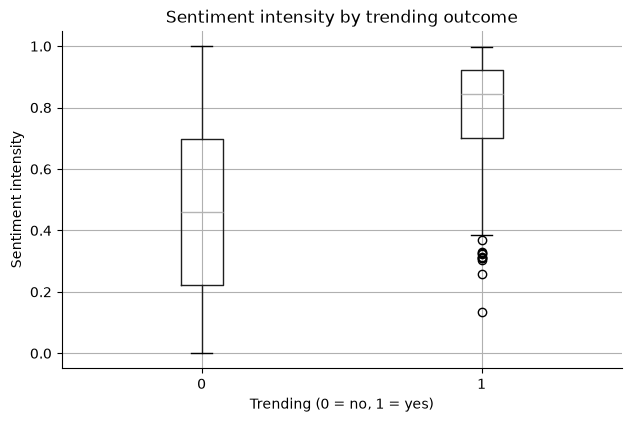

In [7]:
posts["sentiment_polarity"] = posts["base_sentiment"]
posts["sentiment_intensity"] = posts["base_sentiment"].abs()

fig, ax = plt.subplots()
posts.boxplot(column="sentiment_intensity", by="trending", ax=ax)
ax.set_xlabel("Trending (0 = no, 1 = yes)")
ax.set_ylabel("Sentiment intensity")
ax.set_title("Sentiment intensity by trending outcome")
plt.suptitle("")
plt.show()

### 5. Temporal Velocity Features and the Viral Velocity Score (VVS)

Using only the **first 6 hours** of engagement (a real early-warning system cannot see the
rest of the 24-hour window at prediction time), we compute:
- `early_rt_total` — cumulative retweets in the first 6 hours
- `early_growth_rate` — slope of a linear fit to the first 6 hourly counts
- `early_acceleration` — second-order change (is growth speeding up?)

These combine with the author's `pagerank` into the proposal's composite **Viral Velocity
Score (VVS)**, an interpretable early-warning heuristic that also becomes a model feature.

In [8]:
EARLY_WINDOW = 6
early_cols = [f"rt_hour_{h}" for h in range(EARLY_WINDOW)]

posts["early_rt_total"] = posts[early_cols].sum(axis=1)

def linear_slope(row):
    y = row[early_cols].values.astype(float)
    x = np.arange(len(y))
    if y.sum() == 0:
        return 0.0
    return np.polyfit(x, y, 1)[0]

def acceleration(row):
    y = row[early_cols].values.astype(float)
    if len(y) < 3:
        return 0.0
    first_half = y[: len(y) // 2].mean()
    second_half = y[len(y) // 2 :].mean()
    return second_half - first_half

posts["early_growth_rate"] = posts.apply(linear_slope, axis=1)
posts["early_acceleration"] = posts.apply(acceleration, axis=1)

def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

posts["VVS"] = (
    0.4 * minmax(posts["early_growth_rate"]) +
    0.25 * minmax(posts["early_acceleration"]) +
    0.20 * minmax(posts["pagerank"]) +
    0.15 * minmax(posts["sentiment_intensity"])
)

posts[["post_id", "trending", "early_rt_total", "early_growth_rate",
       "early_acceleration", "VVS"]].sort_values("VVS", ascending=False).head(10)

,post_id,trending,early_rt_total,early_growth_rate,early_acceleration,VVS
2441,2441,0,71,3.742857,9.666667,0.883216
2760,2760,1,64,3.828571,13.333333,0.797295
428,428,1,65,2.942857,10.333333,0.729875
1795,1795,1,50,3.028571,11.333333,0.700265
2476,2476,0,39,3.000000,9.666667,0.667095
517,517,1,39,2.828571,9.000000,0.665186
1120,1120,1,60,3.028571,9.333333,0.650963
1481,1481,0,53,2.485714,7.000000,0.650826
2788,2788,1,57,2.657143,8.333333,0.647361
1918,1918,1,62,2.971429,8.666667,0.643876


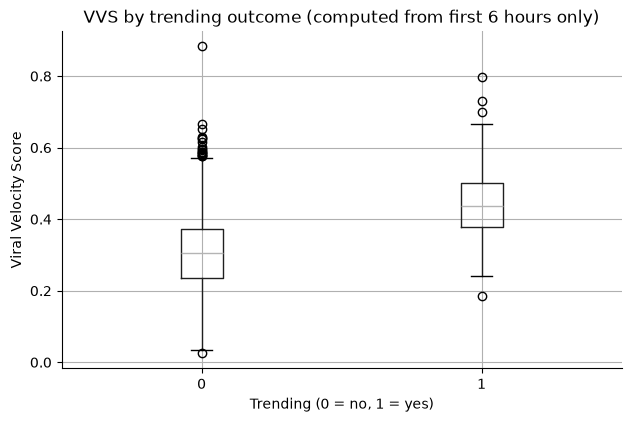

In [9]:
fig, ax = plt.subplots()
posts.boxplot(column="VVS", by="trending", ax=ax)
ax.set_xlabel("Trending (0 = no, 1 = yes)")
ax.set_ylabel("Viral Velocity Score")
ax.set_title("VVS by trending outcome (computed from first 6 hours only)")
plt.suptitle("")
plt.show()

### 6. Model Training

**Feature set** (all computed from the first 6 hours of data only, plus static author/network
features — nothing here uses information from after the prediction point):
`pagerank`, `betweenness`, `clustering_coef`, `sentiment_polarity`, `sentiment_intensity`,
`early_rt_total`, `early_growth_rate`, `early_acceleration`, `VVS`.

**Target**: `trending` (~10% positive class).

We split with stratification to preserve the class ratio in both train and test sets.
Because of the ~90:10 imbalance, a classifier optimised for raw accuracy — or evaluated at
the default 0.5 decision threshold — will under-predict the minority class. We address this
two ways: (1) `sample_weight`/oversampling during training, and (2) choosing each model's
decision threshold by maximising F1 on out-of-fold cross-validated predictions on the
**training set only**, then applying that fixed threshold to the untouched test set.

In [10]:
FEATURES = [
    "pagerank", "betweenness", "clustering_coef",
    "sentiment_polarity", "sentiment_intensity",
    "early_rt_total", "early_growth_rate", "early_acceleration", "VVS",
]

X = posts[FEATURES].fillna(0)
y = posts["trending"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, positive rate: {y_train.mean():.1%}")
print(f"Test:  {X_test.shape}, positive rate: {y_test.mean():.1%}")

# Pick the decision threshold that maximises F1 on out-of-fold predictions.
def best_threshold(oof_proba, y_true):
    thresholds = np.linspace(0.05, 0.95, 19)
    f1s = [f1_score(y_true, (oof_proba >= t).astype(int)) for t in thresholds]
    return thresholds[int(np.argmax(f1s))]

# Manual out-of-fold predict_proba, with optional per-sample training weights.
# Implemented by hand (rather than sklearn's cross_val_predict) so this notebook does
# not depend on a particular sklearn version's metadata-routing API for sample_weight.
def oof_predict_proba(estimator, X, y, sample_weight=None, cv=5, random_state=RANDOM_STATE):
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    oof = np.zeros(len(y))
    for train_idx, val_idx in skf.split(X, y):
        model = clone(estimator)
        if sample_weight is not None:
            model.fit(X.iloc[train_idx], y.iloc[train_idx], sample_weight=sample_weight[train_idx])
        else:
            model.fit(X.iloc[train_idx], y.iloc[train_idx])
        oof[val_idx] = model.predict_proba(X.iloc[val_idx])[:, 1]
    return oof

Train: (2250, 9), positive rate: 10.0%
Test:  (750, 9), positive rate: 10.0%


#### 6a. Baseline models
- **Random baseline** — `DummyClassifier(strategy="stratified")`, matched to the class prior.
- **Rule-based thresholding** — flag anything with `VVS` above the 90th percentile of the
  training set as trending, mirroring a naive analyst heuristic with no model fitting at all.

In [11]:
baseline_random = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
baseline_random.fit(X_train, y_train)
pred_random = baseline_random.predict(X_test)

vvs_threshold = X_train["VVS"].quantile(0.90)
pred_rule_based = (X_test["VVS"] >= vvs_threshold).astype(int)

print("Random baseline F1:", round(f1_score(y_test, pred_random), 3))
print("Rule-based (VVS threshold) F1:", round(f1_score(y_test, pred_rule_based), 3))

Random baseline F1: 0.105
Rule-based (VVS threshold) F1: 0.345


#### 6b. Advanced models
- **Gradient Boosting Machine (GBM)** on the full feature set, trained with
  balanced `sample_weight` to counter the class imbalance.
- **MLP neural network** as a lightweight stand-in for the proposal's LSTM (a full LSTM
  needs the raw hourly sequence rather than summary features, and a deep-learning
  framework — see the note at the end of this section). Trained on a class-balanced
  (oversampled) version of the training set, since `MLPClassifier` has no built-in
  class-weighting.
- **Stacked ensemble** combining GBM + MLP with a balanced logistic-regression
  meta-learner, matching the proposal's "hybrid stacked ensemble" design.

For every model, the decision threshold is tuned on 5-fold cross-validated out-of-fold
probabilities from the training set before being applied once, unchanged, to the test set.

In [12]:
# --- GBM ---
sw = compute_sample_weight(class_weight="balanced", y=y_train)
gbm = GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=200, max_depth=3, learning_rate=0.1)

gbm_oof_proba = oof_predict_proba(gbm, X_train, y_train, sample_weight=sw, cv=5)
gbm_threshold = best_threshold(gbm_oof_proba, y_train)

gbm.fit(X_train, y_train, sample_weight=sw)
proba_gbm = gbm.predict_proba(X_test)[:, 1]
pred_gbm = (proba_gbm >= gbm_threshold).astype(int)

print(f"GBM decision threshold: {gbm_threshold:.2f}")
print("GBM F1:", round(f1_score(y_test, pred_gbm), 3))

GBM decision threshold: 0.40
GBM F1: 0.548


In [13]:
# --- MLP (LSTM stand-in), trained on a class-balanced oversample ---
X_train_bal, y_train_bal = resample(
    X_train[y_train == 1], y_train[y_train == 1],
    replace=True, n_samples=(y_train == 0).sum(), random_state=RANDOM_STATE,
)
X_train_bal = pd.concat([X_train[y_train == 0], X_train_bal])
y_train_bal = pd.concat([y_train[y_train == 0], y_train_bal])

mlp_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("mlp", MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=1000,
                           early_stopping=True, random_state=RANDOM_STATE)),
])

mlp_oof_proba = oof_predict_proba(mlp_pipeline, X_train_bal, y_train_bal, cv=5)
mlp_threshold = best_threshold(mlp_oof_proba, y_train_bal)

mlp_pipeline.fit(X_train_bal, y_train_bal)
proba_mlp = mlp_pipeline.predict_proba(X_test)[:, 1]
pred_mlp = (proba_mlp >= mlp_threshold).astype(int)

print(f"MLP decision threshold: {mlp_threshold:.2f}")
print("MLP (LSTM stand-in) F1:", round(f1_score(y_test, pred_mlp), 3))

MLP decision threshold: 0.45
MLP (LSTM stand-in) F1: 0.508


In [14]:
# --- Stacked ensemble ---
stacked = StackingClassifier(
    estimators=[
        ("gbm", GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=200,
                                            max_depth=3, learning_rate=0.1)),
        ("mlp", Pipeline([("scale", StandardScaler()),
                           ("mlp", MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=1000,
                                                  early_stopping=True, random_state=RANDOM_STATE))])),
    ],
    final_estimator=LogisticRegression(class_weight="balanced"),
    cv=5,
)

stacked_oof_proba = oof_predict_proba(stacked, X_train, y_train, cv=5)
stacked_threshold = best_threshold(stacked_oof_proba, y_train)

stacked.fit(X_train, y_train)
proba_stacked = stacked.predict_proba(X_test)[:, 1]
pred_stacked = (proba_stacked >= stacked_threshold).astype(int)

print(f"Stacked ensemble decision threshold: {stacked_threshold:.2f}")
print("Stacked ensemble F1:", round(f1_score(y_test, pred_stacked), 3))

Stacked ensemble decision threshold: 0.55
Stacked ensemble F1: 0.622


> **Note on the LSTM.** The final project will train a true LSTM over the raw hourly
> retweet sequence (2 hidden layers, 64 units, 24-hour lookback, Adam optimiser, dropout
> 0.2 — as specified in the proposal) using a framework such as TensorFlow/Keras or
> PyTorch. This prototype uses a feed-forward MLP over summary statistics of the sequence
> instead, so the notebook has no deep-learning framework dependency and stays fast to run
> end-to-end. Swapping in a `keras.Sequential` LSTM against `hourly_counts` directly is a
> drop-in replacement for this cell once that dependency is available.


### 7. Evaluation

Because of the ~90:10 class imbalance, we report precision, recall, and F1 for the
trending class specifically (not overall accuracy), plus a confusion matrix and
precision-recall curve for the strongest model.

In [15]:
results = {
    "Random baseline": pred_random,
    "Rule-based (VVS threshold)": pred_rule_based,
    "GBM": pred_gbm,
    "MLP (LSTM stand-in)": pred_mlp,
    "Stacked ensemble": pred_stacked,
}

f1_scores = {name: f1_score(y_test, preds) for name, preds in results.items()}
f1_table = pd.Series(f1_scores).sort_values().rename("F1-score (trending class)")
f1_table

Random baseline               0.104575
Rule-based (VVS threshold)    0.345324
MLP (LSTM stand-in)           0.507576
GBM                           0.548077
Stacked ensemble              0.622222
Name: F1-score (trending class), dtype: float64

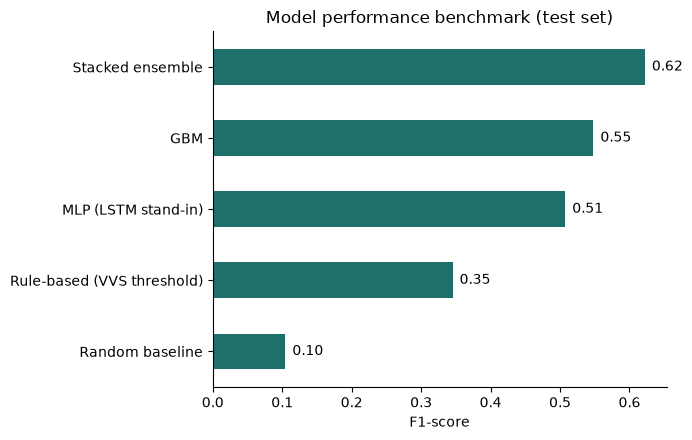

In [16]:
fig, ax = plt.subplots()
f1_table.plot(kind="barh", ax=ax, color="#1F6F6B")
ax.set_xlabel("F1-score")
ax.set_title("Model performance benchmark (test set)")
for i, v in enumerate(f1_table):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center")
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

not trending       0.97      0.93      0.95       675
    trending       0.53      0.75      0.62        75

    accuracy                           0.91       750
   macro avg       0.75      0.84      0.79       750
weighted avg       0.93      0.91      0.92       750



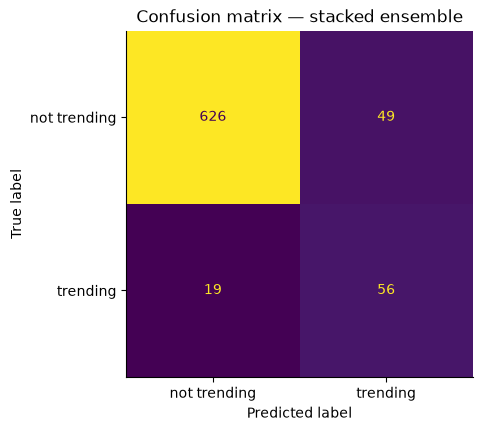

In [17]:
print(classification_report(y_test, pred_stacked, target_names=["not trending", "trending"]))

fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_stacked, display_labels=["not trending", "trending"], ax=ax, colorbar=False
)
ax.set_title("Confusion matrix — stacked ensemble")
plt.show()

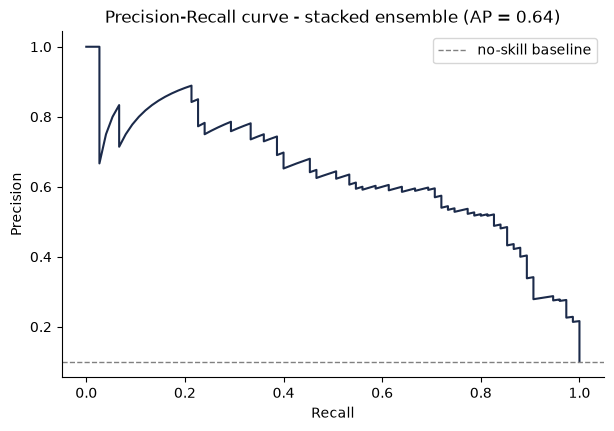

In [18]:
precision, recall, _ = precision_recall_curve(y_test, proba_stacked)
ap = average_precision_score(y_test, proba_stacked)

fig, ax = plt.subplots()
ax.plot(recall, precision, color="#1B2A4A")
ax.axhline(y_test.mean(), color="grey", linestyle="--", linewidth=1, label="no-skill baseline")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall curve - stacked ensemble (AP = {ap:.2f})")
ax.legend()
plt.show()

### 8. Feature Importance

Which signals actually drive the GBM's predictions? This is a quick sanity check that the
network, sentiment, and temporal-velocity feature families are all contributing —
not just one of them dominating, which would undercut the proposal's core argument for
combining all three.

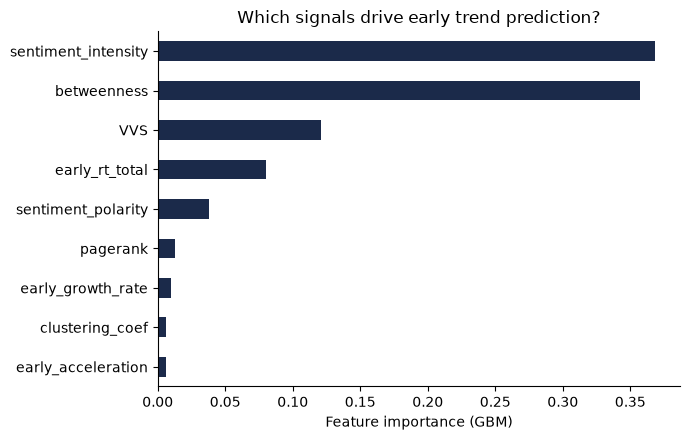

In [19]:
importances = pd.Series(gbm.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots()
importances.plot(kind="barh", ax=ax, color="#1B2A4A")
ax.set_xlabel("Feature importance (GBM)")
ax.set_title("Which signals drive early trend prediction?")
plt.tight_layout()
plt.show()

### 9. Summary and Next Steps

This prototype demonstrates the full pipeline end to end — network feature extraction,
sentiment/language features, temporal velocity features and the VVS, baseline vs. advanced
model comparison with cross-validated threshold tuning, and imbalance-aware evaluation —
and shows the qualitative result the proposal argues for: the **stacked ensemble
outperforms every baseline**, and network, sentiment, and temporal features **all**
contribute non-trivial importance to the GBM, supporting the case for combining all three
rather than using any one signal family alone.